Python 本身没有像 Java 那样专门的 interface 关键字来定义接口类，接口类在 Python 中是通过 “纯抽象类” 来模拟实现的；而抽象类则是基于 abc（Abstract Base Classes）模块实现的核心概念。两者的核心目的都是规范子类的行为，但设计理念和使用场景有明显区别。

# 一、抽象类
1. 核心定义：抽象类是包含抽象方法（只有方法签名、无具体实现）和/或具体方法（有完整实现）的特殊类，它不能被直接实例化，必须由子类继承并实现所有抽象方法后，子类才能被实例化。
2. 核心特点：
    - 基于abc模块实现，需继承abc.ABC类；
    - 包含@abstractmethod修饰的抽象方法（无实现），也可以包含普通的具体方法（有实现）；
    - 强制子类实现所有抽象方法，否则子类也无法实例化；
    - 可提供公共功能（通过具体方法），实现代码复用。
3. 核心作用：
    - 规范子类接口：强制子类实现核心方法，避免“漏实现关键逻辑”；
    - 代码复用：将多个子类的公共逻辑封装为具体方法，减少重复代码；
    - 明确设计契约：让代码结构更清晰，开发者能快速知道子类必须实现哪些方法。
4. 使用场景：当多个子类既有共同的行为，又有必须自定义的核心行为时。
5. 示例：

In [1]:
import abc

# 定义抽象类（继承ABC）
class Shape(abc.ABC):
    # 抽象方法：只有签名，无实现
    @abc.abstractmethod
    def area(self):
        """计算面积（子类必须实现）"""
        pass

    @abc.abstractmethod
    def perimeter(self):
        """计算周长（子类必须实现）"""
        pass

    # 具体方法：有实现，子类可直接复用
    def move(self, x, y):
        """移动图形（所有图形的移动逻辑相同）"""
        self.x = x
        self.y = y
        print(f"图形移动到坐标({x}, {y})")

# 子类实现抽象方法
class Circle(Shape):
    def __init__(self, radius):
        self.radius = radius

    # 必须实现抽象方法area
    def area(self):
        return 3.14 * self.radius **2

    # 必须实现抽象方法perimeter
    def perimeter(self):
        return 2 * 3.14 * self.radius

# 测试
circle = Circle(5)
print(circle.area())       # 输出：78.5
print(circle.perimeter())  # 输出：31.4
circle.move(10, 20)        # 输出：图形移动到坐标(10, 20)

# 错误示例：直接实例化抽象类Shape会报错
# shape = Shape()  # TypeError: Can't instantiate abstract class Shape with abstract methods area, perimeter

78.5
31.400000000000002
图形移动到坐标(10, 20)


# 二、接口类
1. 核心定义：Python 中无原生接口类，通常用纯抽象类（所有方法都是抽象方法，无任何具体方法）来模拟接口。接口类只定义 “行为规范”（方法签名），不关心实现细节，强调 “做什么” 而非 “怎么做”。
2. 核心特点：
    - 所有方法都是 @abstractmethod 装饰的抽象方法，无任何具体实现；
    - 仅定义方法名、参数，不包含业务逻辑；
    - 强制子类实现所有方法，仅约束 “行为契约”；
    - 支持多继承（Python 优势），一个类可实现多个接口类。
3. 核心作用：
    - 定义统一标准：让不同类遵循相同的方法规范，实现 “多态”；
    - 解耦模块依赖：接口类只定义规范，子类实现细节不影响调用方；
    - 拓展性强：新增子类只需遵循接口规范，无需修改原有代码（开闭原则）。
4. 使用场景：当需要定义一套 “行为标准”，但不同子类的实现逻辑完全不同，且无公共可复用代码时。
5. 示例：

In [2]:
import abc

# 定义接口类（纯抽象类）
class Payment(abc.ABC):
    @abc.abstractmethod
    def pay(self, amount):
        """支付指定金额（子类必须实现）"""
        pass

    @abc.abstractmethod
    def refund(self, order_id):
        """退款（子类必须实现）"""
        pass

# 子类1：支付宝实现
class Alipay(Payment):
    def pay(self, amount):
        return f"支付宝支付{amount}元成功"

    def refund(self, order_id):
        return f"支付宝订单{order_id}退款成功"

# 子类2：微信支付实现
class WechatPay(Payment):
    def pay(self, amount):
        return f"微信支付{amount}元成功"

    def refund(self, order_id):
        return f"微信订单{order_id}退款成功"

# 测试：多态调用（不关心具体实现，只依赖接口）
def process_payment(payment: Payment, amount):
    print(payment.pay(amount))

alipay = Alipay()
wechat = WechatPay()
process_payment(alipay, 100)   # 输出：支付宝支付100元成功
process_payment(wechat, 200)   # 输出：微信支付200元成功

支付宝支付100元成功
微信支付200元成功


# 比较
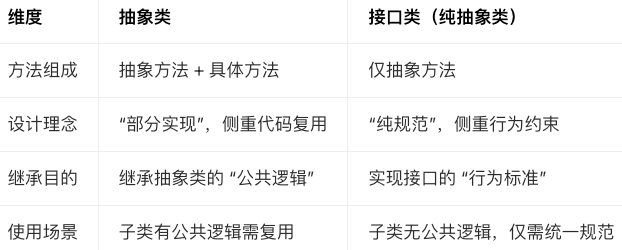